In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/diabetes_binary_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

- No missing values
- Only numerical features

# Recode

### Target Variable

In [4]:
# 0 = no diabetes ; 1 = diabetes

Diabetes_binary = {
    0: "No diabetes",
    1: "Diabetes"
}
Diabetes_binary = Diabetes_binary | {value: key for key, value in Diabetes_binary.items()}
target_cols = {"Diabetes_binary": Diabetes_binary}
print(Diabetes_binary)

{0: 'No diabetes', 1: 'Diabetes', 'No diabetes': 0, 'Diabetes': 1}


### Binary Health Indicators & Demographics

In [5]:
# 0 = no high BP ; 1 = high BP

HighBP = {
    0: "No high BP",
    1: "High BP"
}
HighBP = HighBP | {value: key for key, value in HighBP.items()}
binary_cols = {"HighBP": HighBP}

In [6]:
# 0 = no high cholesterol ; 1 = high cholesterol

HighChol = {
    0: "No high cholesterol",
    1: "High cholesterol"
}
HighChol = HighChol | {value: key for key, value in HighChol.items()}
binary_cols = binary_cols | {"HighChol": HighChol}

In [7]:
# 0 = no cholesterol check in 5 years ; 1 = yes cholesterol check in 5 years

CholCheck = {
    0: "No cholesterol check in 5 years",
    1: "Cholesterol check in 5 years"
}
CholCheck = CholCheck | {value: key for key, value in CholCheck.items()}
binary_cols = binary_cols | {"CholCheck": CholCheck}

In [8]:
# Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no ; 1 = yes

Smoker = {
    0: "No",
    1: "Yes"
}
Smoker = Smoker | {value: key for key, value in Smoker.items()}
binary_cols = binary_cols | {"Smoker": Smoker}

In [9]:
# (Ever told) you had a stroke. 0 = no ; 1 = yes

Stroke = {
    0: "No",
    1: "Yes"
}
Stroke = Stroke | {value: key for key, value in Stroke.items()}
binary_cols = binary_cols | {"Stroke": Stroke}

In [10]:
# coronary heart disease (CHD) or myocardial infarction (MI) 0 = no ; 1 = yes

HeartDiseaseorAttack = {
    0: "No",
    1: "Yes"
}
HeartDiseaseorAttack = HeartDiseaseorAttack | {value: key for key, value in HeartDiseaseorAttack.items()}
binary_cols = binary_cols | {"HeartDiseaseorAttack": HeartDiseaseorAttack}

In [11]:
# physical activity in past 30 days - not including job 0 = no ; 1 = yes

PhysActivity = {
    0: "No",
    1: "Yes"
}
PhysActivity = PhysActivity | {value: key for key, value in PhysActivity.items()}
binary_cols = binary_cols | {"PhysActivity": PhysActivity}

In [12]:
# Consume Fruit 1 or more times per day 0 = no ; 1 = yes

Fruits = {
    0: "No",
    1: "Yes"
}
Fruits = Fruits | {value: key for key, value in Fruits.items()}
binary_cols = binary_cols | {"Fruits": Fruits}

In [13]:
# Consume Vegetables 1 or more times per day 0 = no ; 1 = yes

Veggies = {
    0: "No",
    1: "Yes"
}
Veggies = Veggies | {value: key for key, value in Veggies.items()}
binary_cols = binary_cols | {"Veggies": Veggies}

In [14]:
# Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 drinks per week) 0 = no ; 1 = yes

HvyAlcoholConsump = {
    0: "No",
    1: "Yes"
}
HvyAlcoholConsump = HvyAlcoholConsump | {value: key for key, value in HvyAlcoholConsump.items()}
binary_cols = binary_cols | {"HvyAlcoholConsump": HvyAlcoholConsump}

In [15]:
# Have any kind of health care coverage, including health insurance, prepaid plans such as HMO, etc. 0 = no ; 1 = yes

AnyHealthcare = {
    0: "No",
    1: "Yes"
}
AnyHealthcare = AnyHealthcare | {value: key for key, value in AnyHealthcare.items()}
binary_cols = binary_cols | {"AnyHealthcare": AnyHealthcare}

In [16]:
# Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? 0 = no ; 1 = yes

NoDocbcCost = {
    0: "No",
    1: "Yes"
}
NoDocbcCost = NoDocbcCost | {value: key for key, value in NoDocbcCost.items()}
binary_cols = binary_cols | {"NoDocbcCost": NoDocbcCost}

In [17]:
# Do you have serious difficulty walking or climbing stairs? 0 = no ; 1 = yes

DiffWalk = {
    0: "No",
    1: "Yes"
}
DiffWalk = DiffWalk | {value: key for key, value in DiffWalk.items()}
binary_cols = binary_cols | {"DiffWalk": DiffWalk}

In [18]:
# 0 = female ; 1 = male

Sex = {
    0: "Female",
    1: "Male"
}
Sex = Sex | {value: key for key, value in Sex.items()}
binary_cols = binary_cols | {"Sex": Sex}

### Categorical & Ordinal Scales

In [19]:
# Would you say that in general your health is: scale 1-5 ; 1 = excellent ; 2 = very good ; 3 = good ; 4 = fair ; 5 = poor

GenHlth = {
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor"
}
GenHlth = GenHlth | {value: key for key, value in GenHlth.items()}
ordinal_cols = {"GenHlth": GenHlth}

In [20]:
# Education level (EDUCA see codebook) scale 1-6

Education = {
    1: "Never attended school or only kindergarten",
    2: "Grades 1-8 (Elementary)",
    3: "Grades 9-11 (Some high school)",
    4: "Grade 12 or GED (High school graduate)",
    5: "College 1-3 years (Some college/technical school)",
    6: "College 4 years or more (College graduate)"
}
Education = Education | {value: key for key, value in Education.items()}
ordinal_cols = ordinal_cols | {"Education": Education}

In [21]:
# Income scale (INCOME2 see codebook) scale 1-8

Income = {
    1: "Less than $10,000",
    2: "Less than $15,000",
    3: "Less than $20,000",
    4: "Less than $25,000",
    5: "Less than $35,000",
    6: "Less than $50,000",
    7: "Less than $75,000",
    8: "$75,000 or more"
}
Income = Income | {value: key for key, value in Income.items()}
ordinal_cols = ordinal_cols | {"Income": Income}

In [22]:
# 13-level age category (_AGEG5YR see codebook) 1 = 18-24 ; 9 = 60-64 ; 13 = 80 or older

Age = {
    1: "18-24",
    2: "25-29",
    3: "30-34",
    4: "35-39",
    5: "40-44",
    6: "45-49",
    7: "50-54",
    8: "55-59",
    9: "60-64",
    10: "65-69",
    11: "70-74",
    12: "75-79",
    13: "80 or older"
}
Age = Age | {value: key for key, value in Age.items()}
ordinal_cols = ordinal_cols | {"Age": Age}

### Ordinal - Continuous gray zone

In [23]:
"""Now thinking about your mental health, which includes stress, depression, and problems with emotions,
for how many days during the past 30 days was your mental health not good? scale 1-30 days"""

MentHlth = {
    day: f"Mental health good for {30 - day} days"
    for day in range(31)
}
MentHlth = MentHlth | {value: key for key, value in MentHlth.items()}
gray_cols = {"MentHlth": MentHlth}

In [24]:
"""Now thinking about your physical health, which includes physical illness and injury,
for how many days during the past 30 days was your physical health not good? scale 1-30 days"""

PhysHlth = {
    day: f"Physical health good for {30 - day} days"
    for day in range(31)
}
PhysHlth = PhysHlth | {value: key for key, value in PhysHlth.items()}
gray_cols = gray_cols | {"PhysHlth": PhysHlth}

### Continuous variables

In [25]:
# Body Mass Index

continuous_cols = {"BMI": ""}

### Summary

In [26]:
print("\nTotal: ")
print(target_cols.keys())
print(binary_cols.keys())
print(ordinal_cols.keys())
print(gray_cols.keys())
print(continuous_cols.keys())
print(df.columns)


Total: 
dict_keys(['Diabetes_binary'])
dict_keys(['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'])
dict_keys(['GenHlth', 'Education', 'Income', 'Age'])
dict_keys(['MentHlth', 'PhysHlth'])
dict_keys(['BMI'])
Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='str')


- **Binary** : `target_cols`  `binary_cols`
- **Ordinal** : `ordinal_cols`
- **Continuous** : `gray_cols`  `continuous_cols`

In [27]:
_target_cols = list(target_cols.keys())
_binary_cols = list(binary_cols.keys())
_ordinal_cols = list(ordinal_cols.keys())
_gray_cols = list(gray_cols.keys())
_continuous_cols = list(continuous_cols.keys())

all_cols = {
    "target_cols": _target_cols,
    "binary_cols": _binary_cols,
    "ordinal_cols": _ordinal_cols,
    "gray_cols": _gray_cols,
    "continuous_cols": _continuous_cols
}
print(all_cols)

{'target_cols': ['Diabetes_binary'], 'binary_cols': ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'], 'ordinal_cols': ['GenHlth', 'Education', 'Income', 'Age'], 'gray_cols': ['MentHlth', 'PhysHlth'], 'continuous_cols': ['BMI']}


# Univariate Analysis

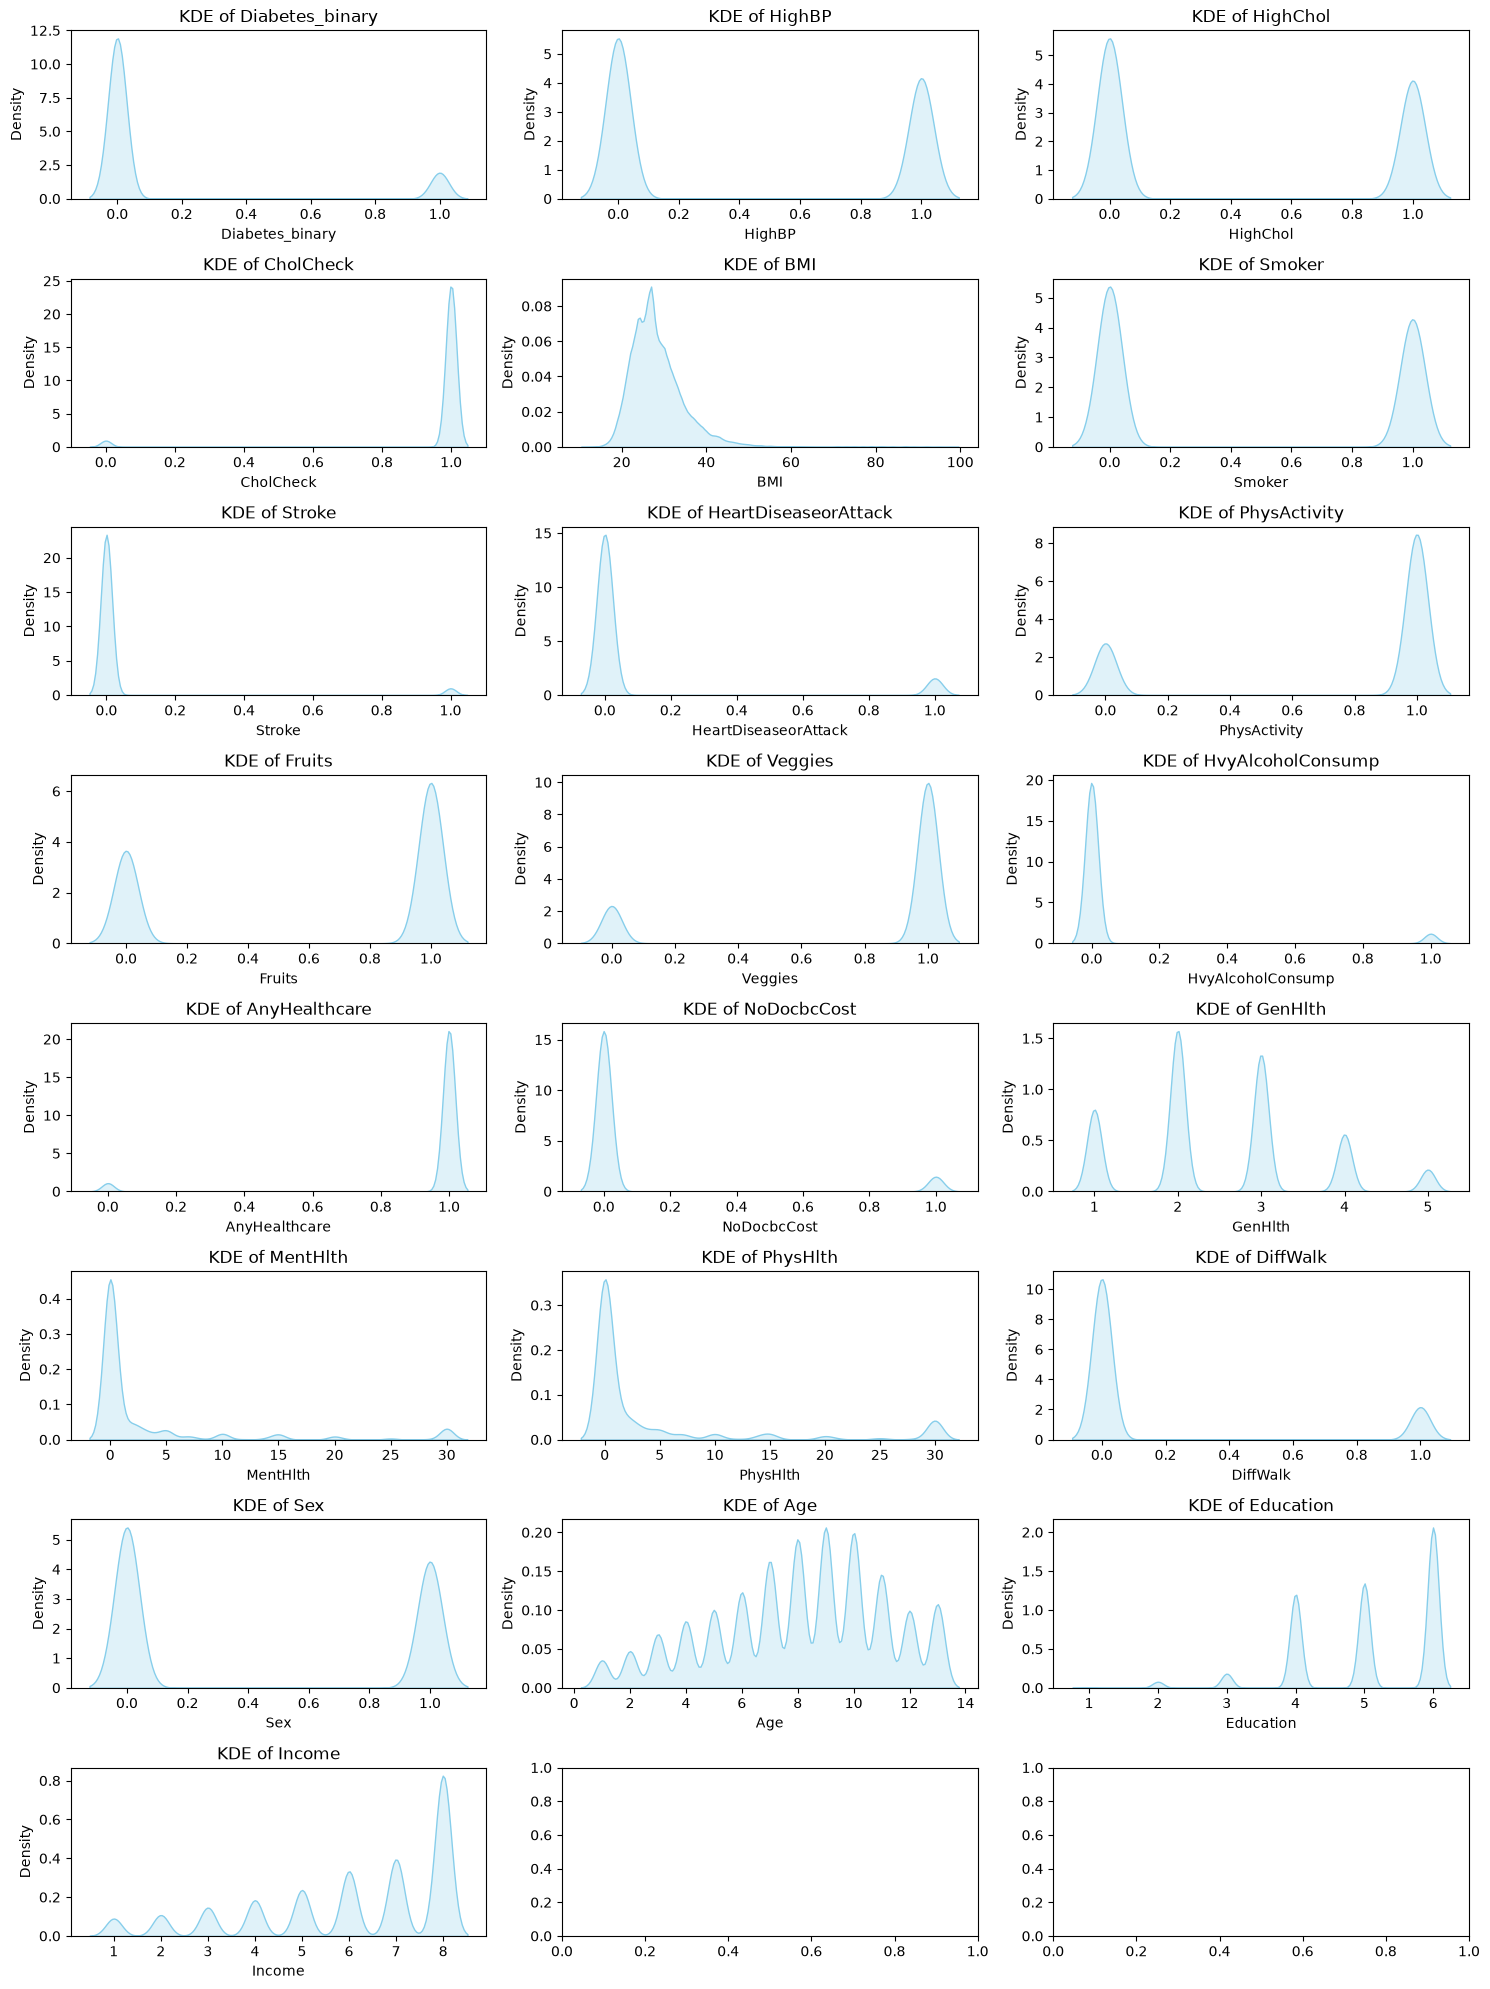

In [28]:
fig, axes = plt.subplots(nrows=8, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.kdeplot(data=df, x=col, ax=axes[i], fill=True, color='skyblue')
    axes[i].set_title(f'KDE of {col}', fontsize=12)

plt.subplots_adjust(wspace=0.35, hspace=1.5)
plt.tight_layout()
plt.show()

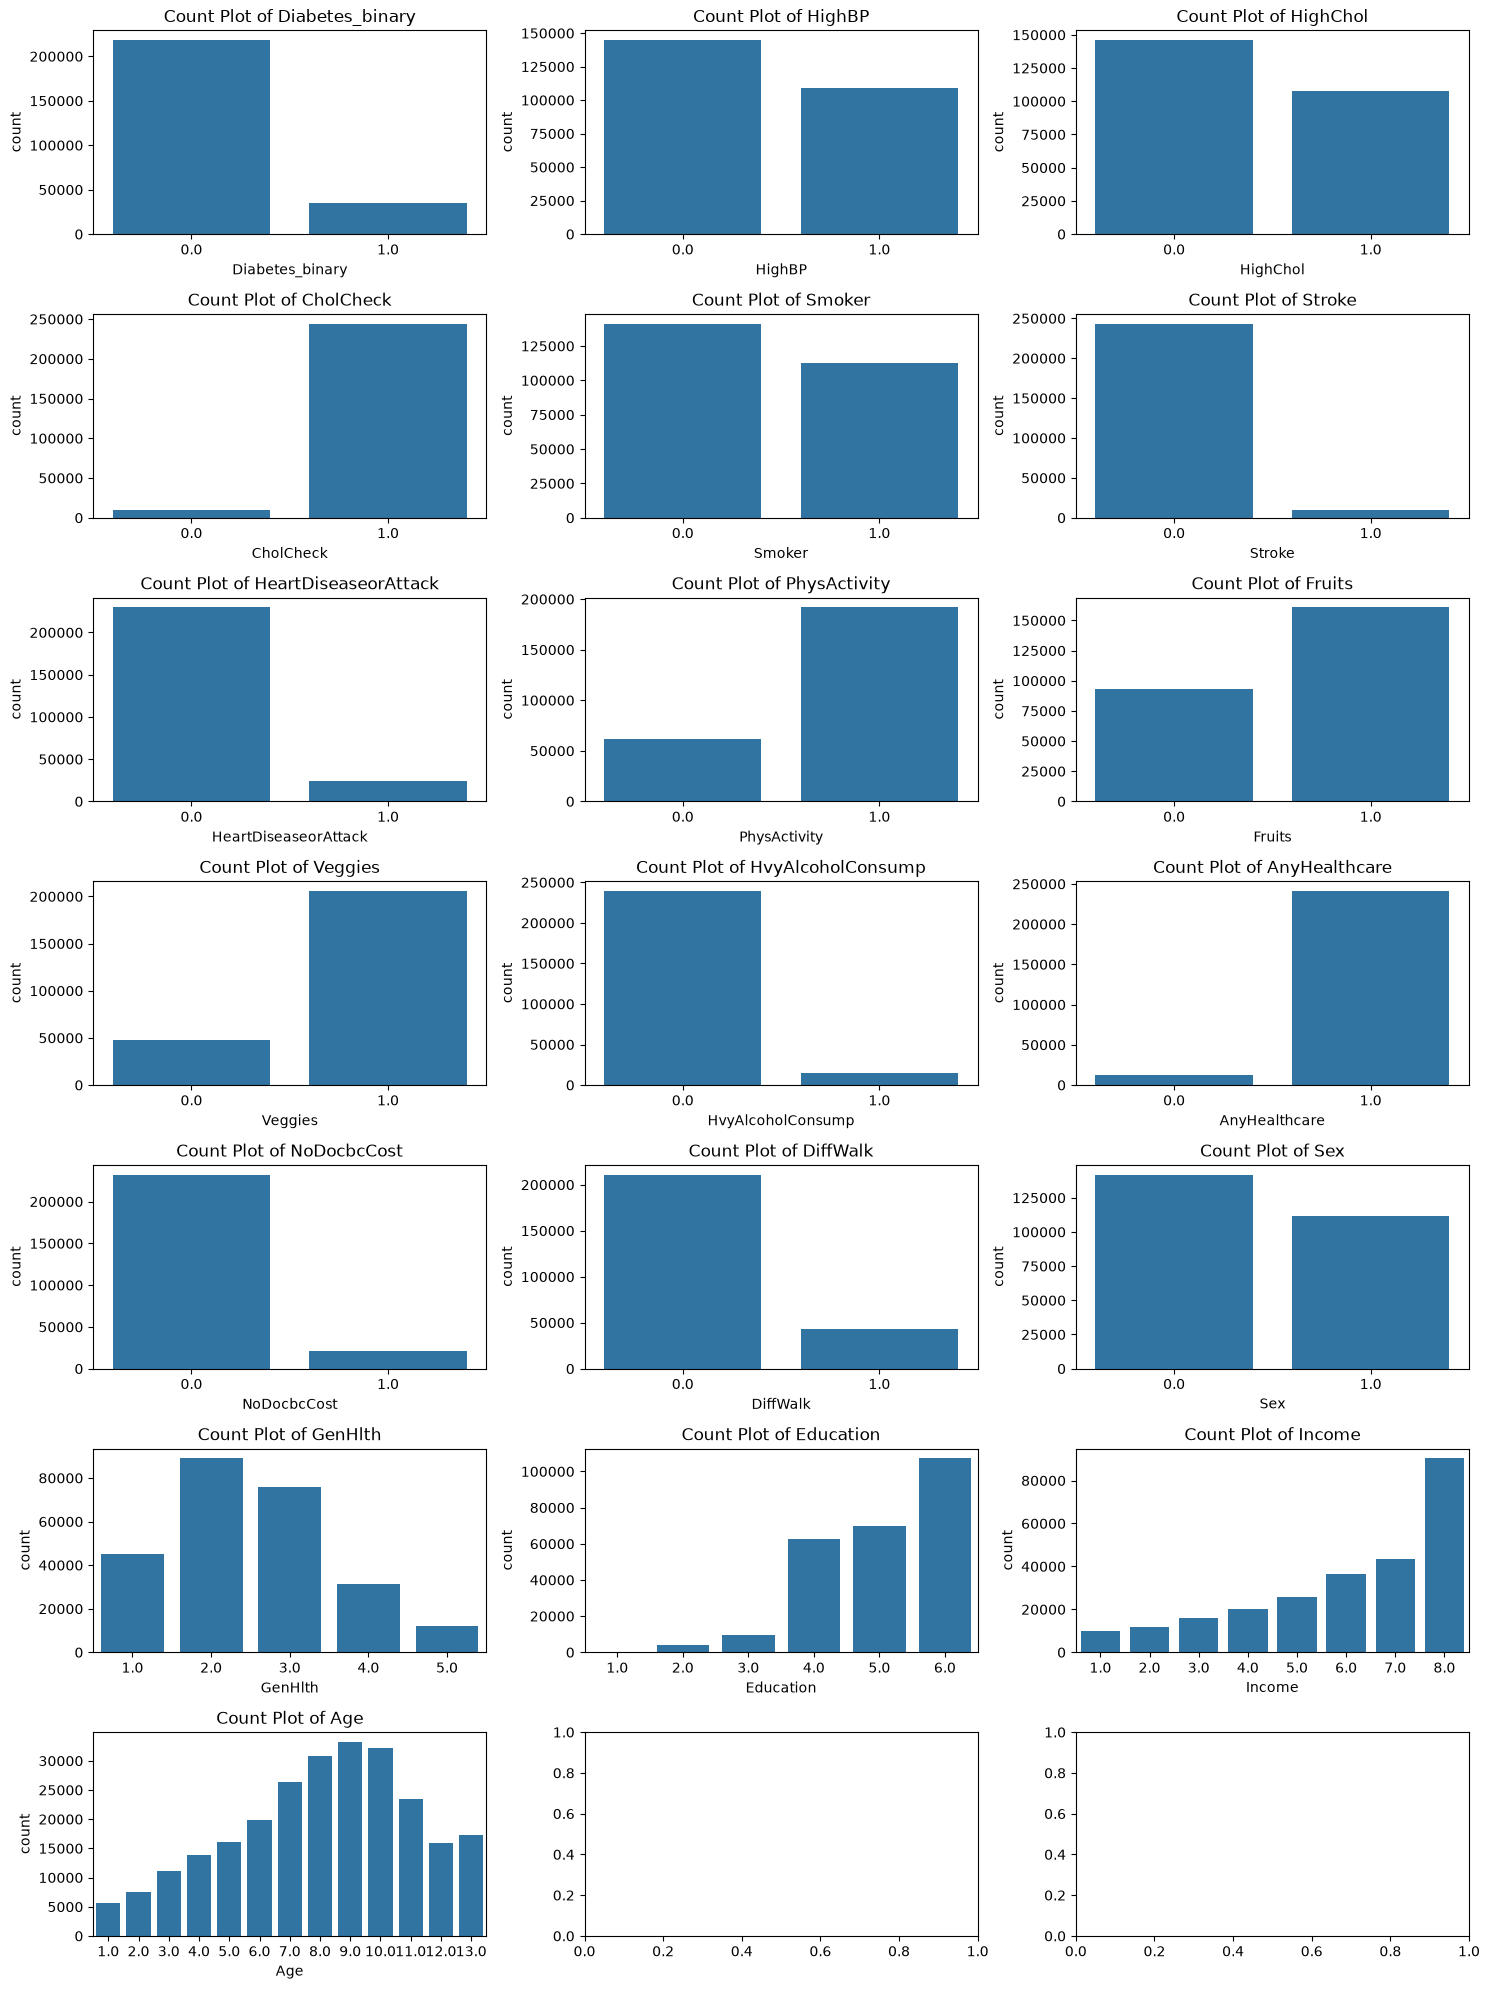

In [29]:
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))
axes = axes.flatten()

cols = _target_cols + _binary_cols + _ordinal_cols
for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}', fontsize=12)

plt.subplots_adjust(wspace=0.35, hspace=1.5)
plt.tight_layout()
plt.show()

# Bivariate Ananlysis

### Correlation rules
```markdown
                     Continuous        Ordinal          Binary             Nominal
                ┌─────────────────┬─────────────────┬────────────────┬────────────────────────┐
     Continuous │    Pearson      │    Spearman     │ Point-Biserial │    ANOVA (R² / η²)     │
                ├─────────────────┼─────────────────┼────────────────┼────────────────────────┤
        Ordinal │    Spearman     │    Spearman     │    Spearman    │  Freeman's Theta / ε²  │
                ├─────────────────┼─────────────────┼────────────────┼────────────────────────┤
         Binary │ Point-Biserial  │    Spearman     │   Cramér's V   │ Cramér's V / Phi [2*2] │
                ├─────────────────┼─────────────────┼────────────────┼────────────────────────┤
        Nominal │ ANOVA (R²/Eta²) │ Freeman's Theta │   Cramér's V   │ Cramér's V / Theil's U │
                └─────────────────┴─────────────────┴────────────────┴────────────────────────┘
```

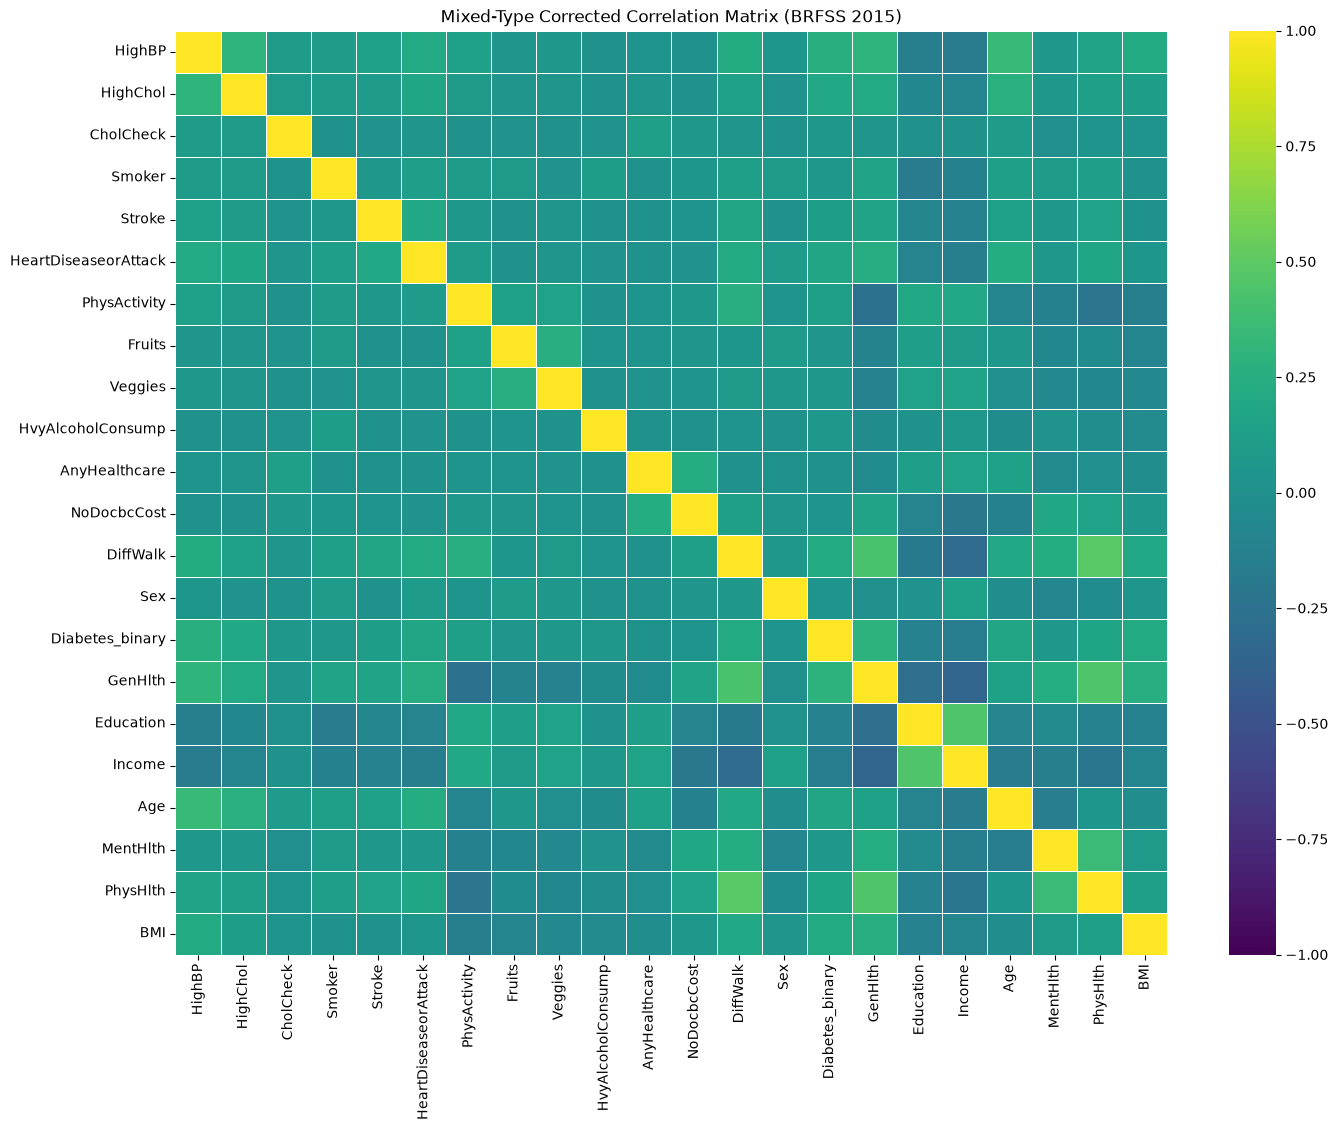

In [30]:
import scipy.stats as stats

_all_cols = _binary_cols + _target_cols + _ordinal_cols + _gray_cols +  _continuous_cols
n = len(_all_cols)

# Initialize an empty matrix
corr_matrix = pd.DataFrame(np.zeros((n, n)), index=_all_cols, columns=_all_cols)

# Calculate the mathematically appropriate correlation for each pair
for i in range(n):
    for j in range(i, n):
        col1, col2 = _all_cols[i], _all_cols[j]

        # Self-correlation is always 1.0
        if col1 == col2:
            corr_matrix.loc[col1, col2] = 1.0
            continue

        val1, val2 = df[col1], df[col2]

        # Scenario A: Both Continuous (Pearson)
        if col1 in (_gray_cols + _continuous_cols) and col2 in (_gray_cols + _continuous_cols):
            r, _ = stats.pearsonr(val1, val2)

        # Scenario B: One Binary, One Continuous (Point-Biserial)
        elif (col1 in (_target_cols + _binary_cols) and col2 in (_gray_cols + _continuous_cols)) or \
            (col1 in (_gray_cols + _continuous_cols) and col2 in _target_cols + _binary_cols):
            r, _ = stats.pointbiserialr(val1, val2)

        # Scenario C: Both Binary (Cramér's V)
        elif col1 in (_target_cols + _binary_cols) and col2 in (_target_cols + _binary_cols):
            # We calculate Cramér's V (which defaults to Phi for 2x2 tables)
            confusion_matrix = pd.crosstab(val1, val2)
            chi2 = stats.chi2_contingency(confusion_matrix)[0]
            n_obs = len(df)
            r = np.sqrt(chi2 / n_obs)  # For 2x2, Cramér's V is exactly sqrt(chi2/N)

        # Scenario D: Anything involving Ordinal columns (Spearman Rank)
        else:
            r, _ = stats.spearmanr(val1, val2)

        # Fill symmetric matrix
        corr_matrix.loc[col1, col2] = r
        corr_matrix.loc[col2, col1] = r

# Plot the mathematically corrected matrix
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap="viridis", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Mixed-Type Corrected Correlation Matrix (BRFSS 2015)")
plt.show()

In [31]:
print("Correlation with Diabetes_binary: ")
print(corr_matrix["Diabetes_binary"].abs().sort_values(ascending=False))

Correlation with Diabetes_binary: 
Diabetes_binary         1.000000
GenHlth                 0.287697
HighBP                  0.263117
DiffWalk                0.218329
BMI                     0.216843
HighChol                0.200265
Age                     0.177684
HeartDiseaseorAttack    0.177263
PhysHlth                0.171337
Income                  0.163305
Education               0.120038
PhysActivity            0.118120
Stroke                  0.105787
MentHlth                0.069315
CholCheck               0.064731
Smoker                  0.060777
HvyAlcoholConsump       0.057032
Veggies                 0.056570
Fruits                  0.040767
Sex                     0.031419
NoDocbcCost             0.031412
AnyHealthcare           0.016229
Name: Diabetes_binary, dtype: float64
